# <center>Segmentación de clientes de un centro comercial</center>

### Objetivo:
- Clasificar o agrupar a los clientes del centro comercial basándose en características numéricas y categóricas.
- Se trata de un problema de **aprendizaje no supervisado**.

### <center>Atributos del conjunto de datos</center>

- **CustomerID** : Identificador único asignado al cliente
- **Gender** : Género del cliente
- **Age** : Edad del cliente
- **Annual Income (k$)** : Ingresos anuales del cliente
- **Spending Score (1-1000)** : Puntuación asignada por el centro comercial basada en el comportamiento del cliente y sus hábitos de gasto

### Contenido del notebook:
- Información del conjunto de datos
- Análisis exploratorio de datos (EDA)
- Resumen del EDA
- Ingeniería de características
- Modelado
- Conclusión

### Lo que aprenderás:
- Técnicas de visualización de datos.
- Información sobre el algoritmo de agrupamiento K-Means.
- Pruebas estadísticas para la selección de hiperparámetros.
- Diferencias en el rendimiento del modelo al entrenarlo con el conjunto de datos original frente al normalizado.

### Trabajos recientes:

- [Clasificación binaria](https://www.kaggle.com/competitions/titanic/discussion/352223) **: Describe el enfoque necesario para abordar problemas de clasificación binaria mediante notebooks que presentan trabajos realizados con conjuntos de datos, incluyendo explicaciones del código claras y fáciles de entender.**
- [Análisis de series temporales](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/discussion/352205) **: Describe los fundamentos del análisis de series temporales mediante notebooks que presentan trabajos realizados con conjuntos de datos, incluyendo explicaciones del código claras y fáciles de entender.**

### ¡Empecemos!

# <center>Dataset Information</center>

### Import the Necessary Libraries :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [3]:
data = pd.read_csv('Mall_Customers.csv')
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Información del conjunto de datos :

In [4]:
data.shape

(200, 5)

In [5]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


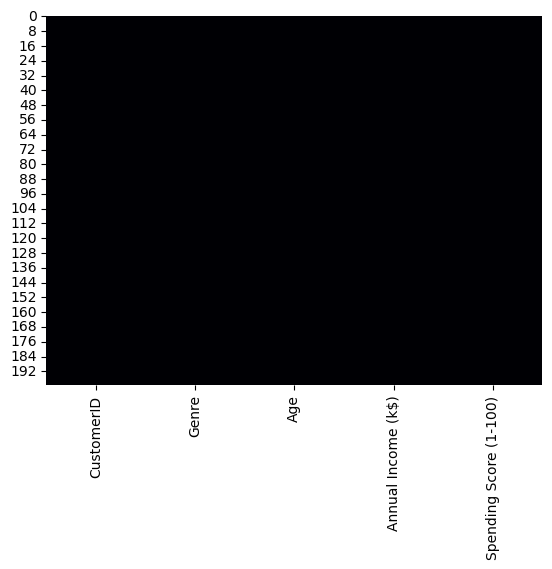

In [7]:
sns.heatmap(data.isnull(),cmap = 'magma',cbar = False);

- ¡No hay valores nulos presentes en los datos!

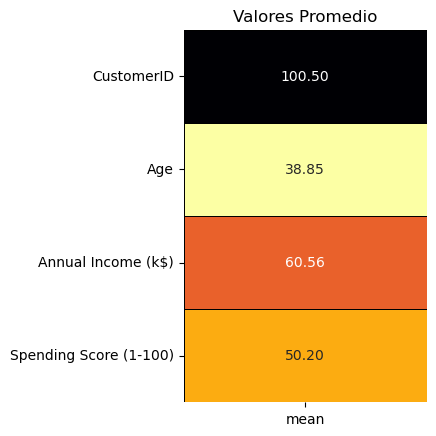

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

plt.subplot(1, 1, 1)
sns.heatmap(
    data.describe().T[['mean']],
    cmap='inferno_r',
    annot=True,
    fmt='.2f',
    linecolor='black',
    linewidths=0.4,
    cbar=False
)

plt.title('Valores Promedio')

fig.tight_layout(pad=3)

- El promedio de edad del cliente en el conjunto de datos está a finales de los 30, es decir **38.85**.
- El promedio de **Ingreso Anual (k$)** de los clientes es **60.56**, es decir, apenas por debajo del ingreso mediano de 2018 de un ciudadano estadounidense, 63k$.
- El promedio de **Spending Score (1-100)** de los clientes del centro comercial está en el centro con **50.20**.

# <center>Análisis Exploratorio de Datos</center>

### División de características en Numéricas y Categóricas :

In [10]:
col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : Genre
Numerical Features : CustomerID Age Annual Income (k$) Spending Score (1-100)


- Aquí, las características se definen como categóricas si el atributo tiene menos de 6 elementos únicos; de lo contrario, es una característica numérica.
- Un enfoque típico para esta división también puede basarse en los tipos de datos de los elementos del atributo respectivo.

**Ej :** tipo de datos = entero, atributo = característica numérica ; tipo de datos = cadena, atributo = característica categórica

- Para este conjunto de datos, como el número de características es pequeño, también podemos verificar el conjunto de datos manualmente.

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep = True)

df1['Genre'] = le.fit_transform(df1['Genre'])

print('Label Encoder Transformation')
print(df1['Genre'].unique(),' = ',le.inverse_transform(df1['Genre'].unique()))

Label Encoder Transformation
[1 0]  =  ['Male' 'Female']


In [13]:
print(data.columns.tolist())

['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


- Creando una copia profunda del conjunto de datos original y codificando con etiquetas los datos de texto de **Gender**.
- Las modificaciones en el conjunto de datos original no se reflejarán en esta copia profunda.
- Por lo tanto, usamos esta copia profunda del conjunto de datos que tiene **Gender** convertido en valores numéricos para fines de visualización y modelado.

### Distribución de las características categóricas y numéricas :

C:\Users\derek\AppData\Local\Temp\ipykernel_10280\2039315377.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
d:\Anaconda\Lib\site-packages\seaborn\distributions.py:2496: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=1`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
C:\Users\derek\AppData\Local\Temp\ipykernel_10280\2039315377.py:11: UserWarning: 

`distplot` is a deprecated function and will be remov

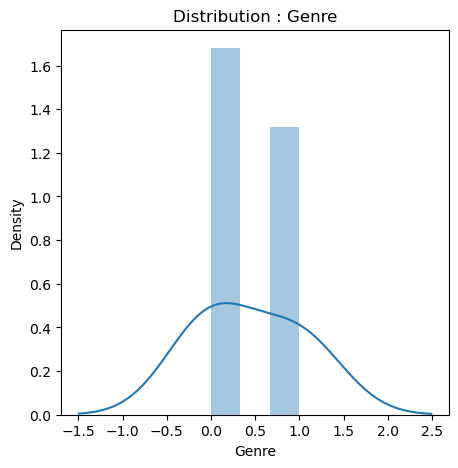

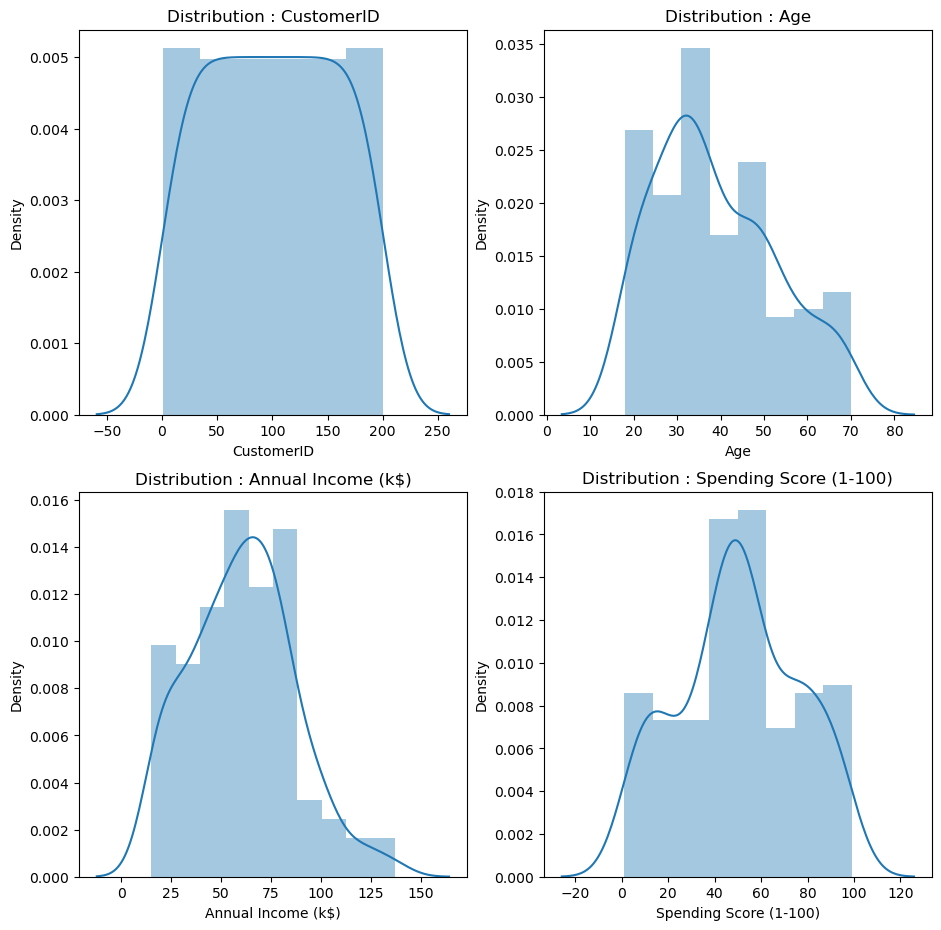

In [15]:
fig, ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))
for i in range(len(categorical_features)):
    plt.subplot(1,1,i+1)
    sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
    title = 'Distribution : ' + categorical_features[i]
    plt.title(title)
    
fig, ax = plt.subplots(nrows = 2,ncols = 2,figsize = (11,11))
for i in range(len(numerical_features)):
    plt.subplot(2,2,i+1)
    sns.distplot(data[numerical_features[i]],)
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

- **Gender**, la única característica categórica, muestra una distribución **normal**.
- La distribución de **Age** y **Annual Income (k$)** está **sesgada positivamente o hacia la derecha**.
- La distribución de **Spending Score (1-100)** es similar al patrón de **Head and Shoulders** observado en gráficos de acciones.
- Muestra el precio de una acción subiendo hasta un pico y luego descendiendo de nuevo al nivel anterior. Algo similar se observa con los **2 hombros** que se forman alrededor de los valores **20 y 80**, siendo la **cabeza** centrada entre **40 - 60**.
- Eliminaremos la característica **CustomerID** ya que es solo un número asignado a un cliente.

In [16]:
numerical_features.remove('CustomerID')

### Características Categóricas :

C:\Users\derek\AppData\Local\Temp\ipykernel_10280\3064336420.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])


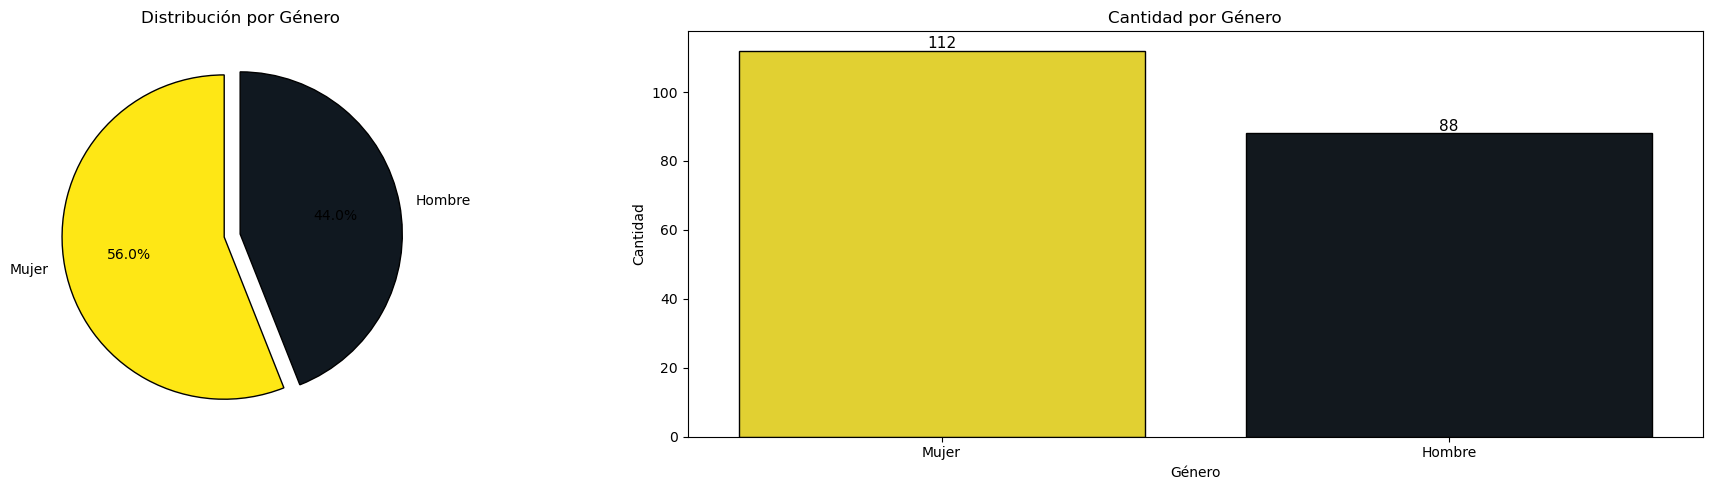

In [19]:
l = list(data['Genre'].value_counts())

circle = [
    l[0] / sum(l) * 100,
    l[1] / sum(l) * 100
]

colors = ['#FEE715', '#101820']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

# Gráfica de pastel
plt.subplot(1, 2, 1)

plt.pie(
    circle,
    labels=['Mujer', 'Hombre'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.1, 0),
    colors=colors,
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 1,
        'antialiased': True
    }
)

plt.title('Distribución por Género')


# Gráfica de barras
plt.subplot(1, 2, 2)

ax = sns.countplot(
    x='Genre',
    data=df1,
    palette=colors,
    edgecolor='black',
    hue='Genre',
    legend=False
)

for rect in ax.patches:
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 0.75,
        int(rect.get_height()),
        horizontalalignment='center',
        fontsize=11
    )

plt.title('Cantidad por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad')

ax.set_xticklabels(['Mujer', 'Hombre'])

plt.tight_layout()
plt.show()

- Para el conjunto de datos anterior, las clientes **mujeres** superan por poco a los clientes **hombres**.

### Características Numéricas vs Características Categóricas :

C:\Users\derek\AppData\Local\Temp\ipykernel_10280\3972980304.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])
C:\Users\derek\AppData\Local\Temp\ipykernel_10280\3972980304.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])
C:\Users\derek\AppData\Local\Temp\ipykernel_10280\3972980304.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])
C:\Users\derek\AppData\Local\Temp\ipykernel_10280\3972980304.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])
C:\Users\derek\AppData\Local\Temp\ipykernel_1028

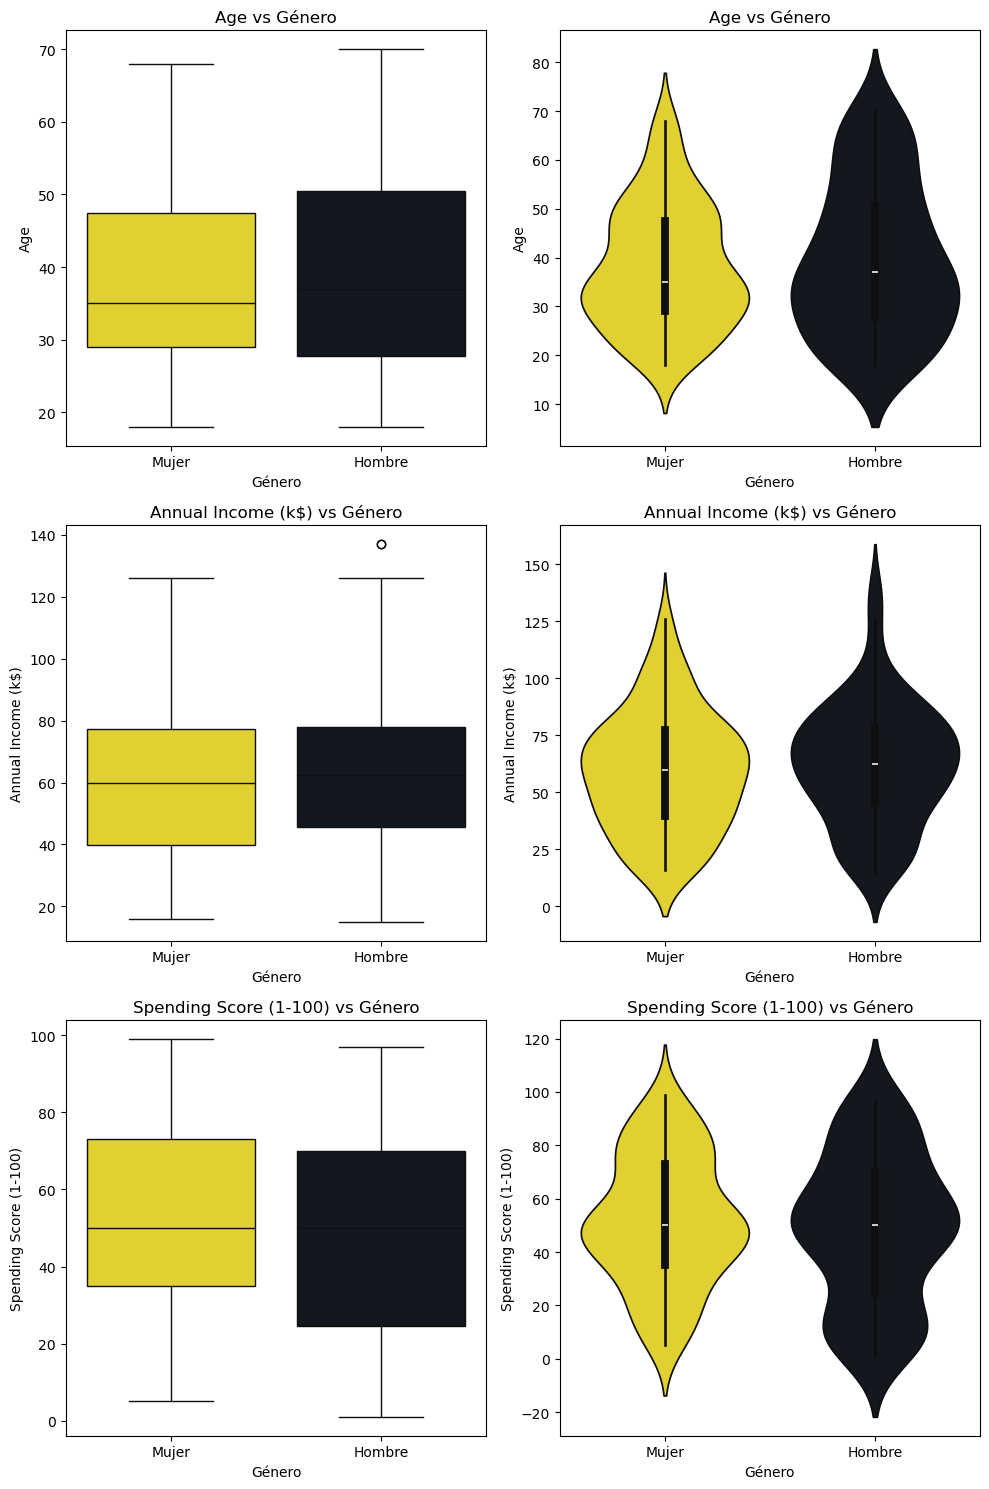

In [21]:
fig = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))

for i in range(len(numerical_features)):

    # Gráfica Boxplot
    plt.subplot(3, 2, (i * 2) + 1)

    ax = sns.boxplot(
        x='Genre',
        y=numerical_features[i],
        data=df1,
        hue='Genre',
        palette=colors,
        legend=False
    )

    ax.set_xticklabels(['Mujer', 'Hombre'])

    title = numerical_features[i] + ' vs Género'
    plt.title(title)
    plt.xlabel('Género')
    plt.ylabel(numerical_features[i])


    # Gráfica Violinplot
    plt.subplot(3, 2, (i * 2) + 2)

    ax = sns.violinplot(
        x='Genre',
        y=numerical_features[i],
        data=df1,
        hue='Genre',
        palette=colors,
        legend=False
    )

    ax.set_xticklabels(['Mujer', 'Hombre'])

    title = numerical_features[i] + ' vs Género'
    plt.title(title)
    plt.xlabel('Género')
    plt.ylabel(numerical_features[i])

plt.tight_layout()
plt.show()

- El rango de **Age** de las clientes **mujeres** es de **30 a poco menos de 50**, mientras que en los clientes **hombres** el rango de **Age** es de **poco menos de 30 a 50**.
- Para ambos **géneros**, se observa un aumento en la edad de **30 - 35**. La mediana de **Age** de los clientes **hombres** es ligeramente mayor que la de las **mujeres**.
- Para **Annual Income (k$)**, el ingreso de las clientes **mujeres** comienza en **40k**, mientras que el de los clientes **hombres** está por encima de este valor.
- La mediana de **Annual Income (k$)** para ambos **géneros** está cerca de **60k**. El **Annual Income (k$)** de los clientes **hombres** se reduce muy bruscamente en el extremo superior, con algunos valores atípicos en comparación con los clientes **mujeres**.
- La mediana de **Spending Score (1-100)** de ambos **géneros** es la misma, a pesar de tener diferentes puntos de partida de **poco menos de 40** y **poco más de 20** para los clientes **mujeres** y **hombres**, respectivamente.
- Ambos **géneros** muestran un fuerte aumento en el valor mediano, especialmente los clientes **mujeres**. Sin embargo, los clientes **hombres** también muestran un aumento pequeño pero significativo en el rango de **0 - 20**.

### Características Numéricas vs Características Numéricas respecto a la Característica Categórica :

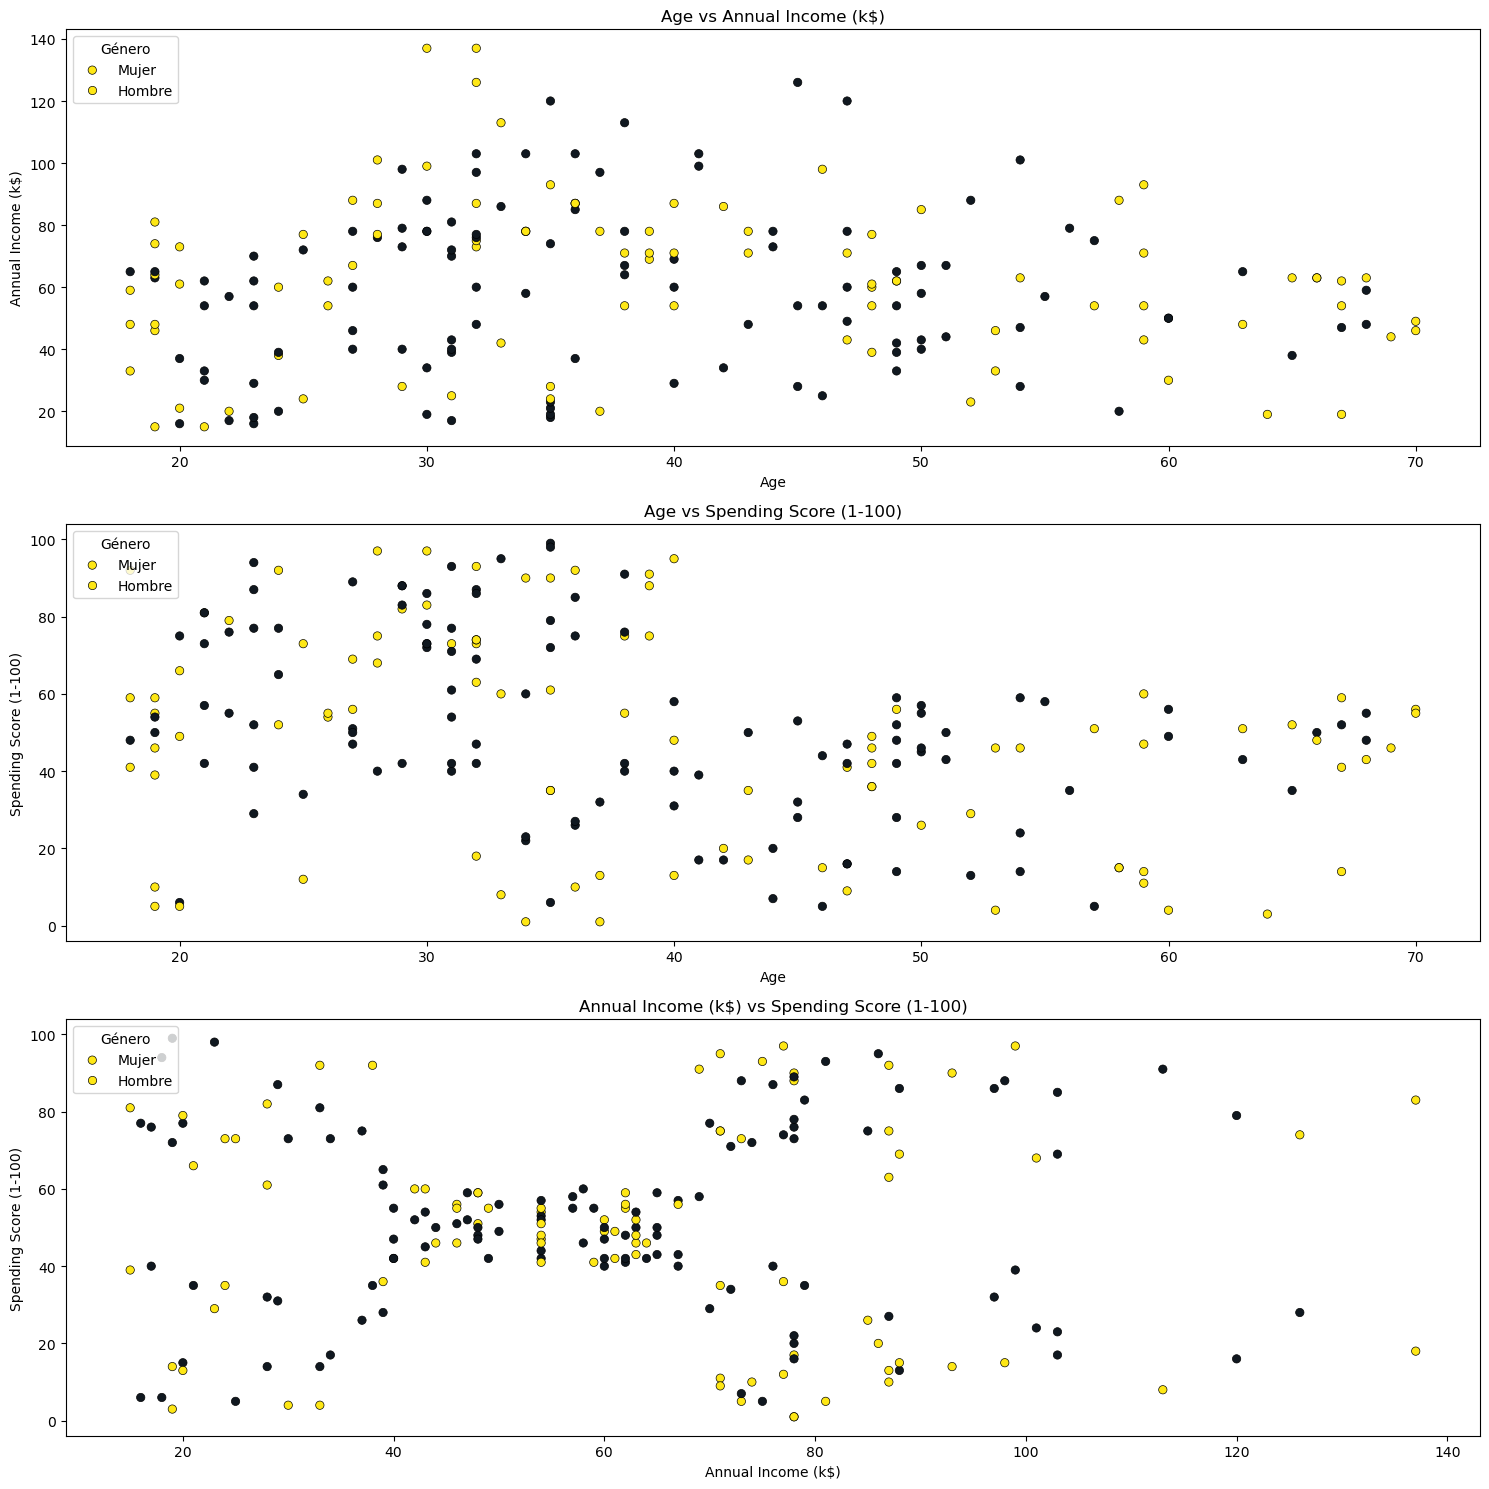

In [22]:
a = 0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15, 15))

for i in range(len(numerical_features) - 1):
    for j in range(len(numerical_features)):

        if i != j and j > i:
            a += 1

            plt.subplot(3, 1, a)

            sns.scatterplot(
                x=numerical_features[i],
                y=numerical_features[j],
                data=data,
                hue='Genre',
                palette=colors,
                edgecolor='black'
            )

            plt.legend(
                title='Género',
                labels=['Mujer', 'Hombre'],
                loc='upper left'
            )

            title = (
                numerical_features[i]
                + ' vs '
                + numerical_features[j]
            )

            plt.title(title)
            plt.xlabel(numerical_features[i])
            plt.ylabel(numerical_features[j])

plt.tight_layout()
plt.show()

- Los puntos de datos de **Annual Income (k$)** están presentes en todos los valores de **Age**, **Gender** no aporta información significativa.
- Para **Spending Score (1-100)**, se puede observar claramente que los rangos de **Age** **20 - 30** muestran hábitos de gasto muy altos.
- El grupo de **Age** **30 - 40** muestra ambos extremos de comportamiento de gasto de los clientes. El grupo de clientes de **40 - 70 años** muestra el otro extremo del comportamiento de gasto con valores bajos.
- En **Annual Income (k$) vs Spending Score (1-100)**, se pueden observar 5 grupos distintos. Para valores de **Annual Income (k$)** entre **0 - 40**, los datos muestran 2 grupos de clientes con **Spending Score (1-100)** entre **0 - 40** y **60 - 100**.
- Después de mostrar este extremo, los datos resaltan el grupo intermedio de clientes que tienen un **Annual Income (k$)** entre **40 - 70k** y un **Spending Score (1-100)** entre **40 - 60**.
- Los valores de **Annual Income (k$)** entre **70 - 140k** definen el otro extremo que se divide en 2 grupos según los valores de **Spending Score (1-100)** de **0 - 40** y **60 - 100**.

# <center>Resumen del EDA</center>

- Para los datos del centro comercial anterior, las clientes **mujeres** son más que los clientes **hombres**. Los datos de **Gender** están bastante equilibrados respecto a las otras características.
- Los clientes del centro comercial se pueden dividir por sus grupos de **Age** :
    - **20 - 30**
    - **30 - 40**
    - **40 - 70**.
- La mediana de **Annual Income (k$)** de ambos **géneros** es aproximadamente **60k**. Muestra 3 grupos de valores :
    - **0 - 40k**
    - **40 - 70k**
    - **70 - 140k**.
- El **Spending Score (1-100)** de las **mujeres** es más alto que el de los **hombres**. También puede dividir a los clientes en 3 grupos :
    - **0 - 40**
    - **40 - 60**
    - **60 - 100**
- Usando la combinación de los valores anteriores, los **clientes del centro comercial** se pueden segmentar, lo que permite una atención específica para cada grupo.

# <center>Ingeniería de Características</center>

### Matriz de Correlación :

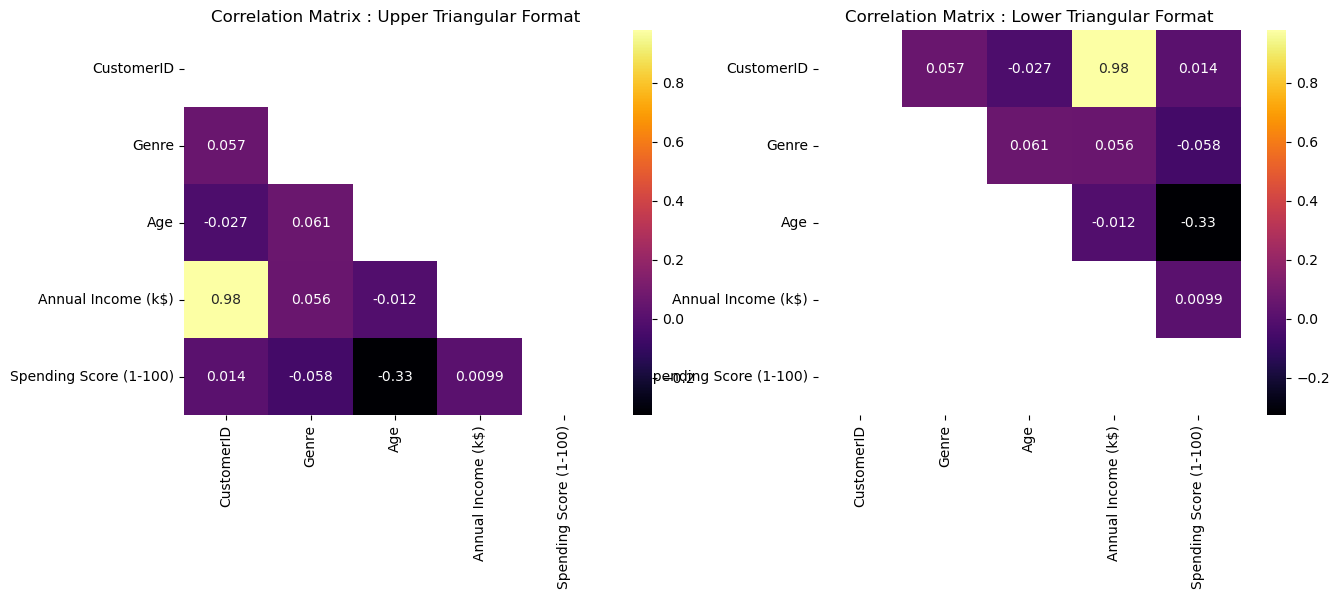

In [24]:
ut = np.triu(df1.corr())
lt = np.tril(df1.corr())

fig,ax = plt.subplots(nrows = 1, ncols = 2,figsize = (15,5))
plt.subplot(1,2,1)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = ut);
plt.title('Correlation Matrix : Upper Triangular Format');

plt.subplot(1,2,2)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = lt);
plt.title('Correlation Matrix : Lower Triangular Format');

df1.drop(columns = 'CustomerID',inplace = True)

- ¡Ambas matrices mostradas son iguales! Esto se hace solo con fines de visualización. Este truco puede usarse cuando el conjunto de datos tiene demasiadas características para revisar.
- **CustomerID** muestra una correlación positiva muy alta con **Annual Income (k$)** ya que los clientes están ordenados en orden ascendente según su **Annual Income (k$)**. No vamos a incluir **CustomerID** para fines de modelado.
- **Gender** no muestra ninguna relación con otras características. Es bastante neutro, con todos los valores cerca de 0.
- **Spending Score (1-100)** y **Age** muestran una correlación negativa, es decir, si el valor de una característica aumenta, el valor de la otra disminuye y viceversa.
- Esta información se obtiene de la sección de **EDA**, los valores de la matriz de correlación respaldan la evidencia.
- Ahora pasaremos a la sección de modelado creando combinaciones de estas características y encontrando diferentes formas en las que se pueden segmentar los clientes del centro comercial.

### Escalado de Datos :

- El modelo de aprendizaje automático no entiende las unidades de los valores de las características. Trata la entrada simplemente como un número y no entiende el verdadero significado de ese valor. Por lo tanto, es necesario escalar los datos.

- Tenemos 2 opciones para el escalado de datos :
    
    1) **Normalización**
    
    2) **Estandarización**.


- Como la mayoría de los algoritmos asumen que los datos están distribuidos normalmente (Gaussiano), la **Normalización** se realiza para características que no muestran una distribución normal y se realiza la **estandarización** para características que están distribuidas de forma normal pero cuyo rango de valores es muy grande o muy pequeño en comparación con otras características.

- Para el conjunto de datos anterior, hemos realizado la **Normalización** para 3 características: **Age**, **Annual Income (k$)** y **Spending Score (1-100)**. La característica **Gender** se deja sin cambios.

In [25]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

# Label Encoding 
df2 = df1.copy(deep = True)

# Normalization
df2['Age'] = mms.fit_transform(df2[['Age']])
df2['Annual Income (k$)'] = mms.fit_transform(df2[['Annual Income (k$)']])
df2['Spending Score (1-100)'] = mms.fit_transform(df2[['Spending Score (1-100)']])

- Para resaltar la diferencia entre el rendimiento de los modelos cuando se entrenan con el conjunto de datos original y con el conjunto normalizado, creamos una copia del conjunto de datos original y aplicamos la transformación de normalización en él.

**¡Ahora pasaremos a la sección de modelado!**

# <center>Modelado</center>

- **Aprendizaje No Supervisado** : Es un problema donde la variable/etiqueta objetivo es desconocida. Los problemas de **Aprendizaje No Supervisado** ocurren ampliamente en el dominio médico, donde se toman múltiples lecturas y las enfermedades subyacentes son desconocidas.
- Por lo tanto, buscar patrones usando técnicas de visualización nos proporciona una visión subyacente que no puede entenderse observando solo los datos en forma tabular.
- Sin embargo, cuando el tamaño de los conjuntos de datos se vuelve grande con demasiadas características, la visualización de datos puede ser una tarea tediosa de ejecutar. Por eso pasamos al algoritmo de **Clustering K-Means**, que **no admite características categóricas**.
- Es el algoritmo más preferido para tratar problemas de **Aprendizaje No Supervisado** que hace el trabajo de encontrar clústeres/grupos en los datos pero con un enfoque matemático :
    - Selecciona 2 centroides al azar (supongamos k = 2).
    - Se calcula la distancia entre los centroides y todos los puntos de datos.
    - Si el punto de datos está más cerca de uno de los centroides, entonces se etiqueta como ese centroide y viceversa.
    - Para los 2 clústeres formados, se calcula el valor promedio de los puntos de datos agrupados con cada centroide, y estos valores promedio se definen luego como los nuevos clústeres.
    - Este proceso se repite hasta que ambos centroides convergen en puntos fijos.
- **Hiperparámetro k** : Define el número de clústeres o grupos en los que se debe dividir el conjunto de datos. Para seleccionar los valores de **k**, usamos 2 pruebas estadísticas :
    - **Método del Codo** : Es un método que traza la suma del error cuadrático para un rango de valores de **k**. Si este gráfico se parece a un brazo, entonces **k** es el valor que se asemeja a un **codo**. A partir de este valor de **codo**, la suma de los valores cuadrados (inercia) comienza a disminuir de forma lineal y por eso se considera un valor óptimo.
    - **Método de la Puntuación de Silueta** : Es un método que evalúa la calidad de los clústeres en términos de qué tan bien los puntos de datos están agrupados con otros puntos similares. Esta puntuación se calcula usando la fórmula de distancia y se selecciona para el modelado el valor de **k** con la puntuación más alta.
    
**Ahora crearemos modelos entrenándolos en la combinación de características seleccionadas a partir de las pruebas anteriores y los visualizaremos también.**